Анализ с момента когда есть предобработанные датасеты

Data preparation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
comments = pd.read_csv('/content/drive/MyDrive/Диплом_Артема_Хугаева/cleaned_comments.csv')

In [5]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

ru_stopwords = set(stopwords.words("russian"))
keep_words = {"не", "нет", "ни"}
ru_stopwords = ru_stopwords - keep_words
custom_stopwords = {
    "это", "весь", "который", "очень", "ещё",
    "свой", "наш", "ваш", "просто", "вообще",
    "сказать", "говорить", "всё", "хотя", "год", "человек", "мочь", "делать", "сделать", "знать",
    "первый", "второй", "большой", "хороший", "время",
    "работать", "работа", "вопрос", "страна", "случай",
    "думать", "хотеть", "почему", "нужно", "дело",
    "каждый", "самый", "пока", "никто", "дать", "давать", "нет",
     "видео", "перейти", "писать",
    "дом", "искать", "любить",
    "украина", "сша", "война", "президент", "военный", "что-то", "какой-то", "также",
    "например", "кошечка"
}



ru_stopwords = ru_stopwords | custom_stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Процессим данные для topic modeling

In [14]:
def prepare_for_topic(text: str) -> str:
    words = text.split()
    words = [w for w in words if w not in ru_stopwords and len(w) > 2]
    return " ".join(words)

posts["text_topic"] = posts["text_lemma"].apply(prepare_for_topic)
comments["text_topic"] = comments["text_lemma"].apply(prepare_for_topic)
threads["text_topic"] = threads["text_lemma"].apply(prepare_for_topic)

Процессим для sentiment

In [15]:
#sentiment

def prepare_for_sentiment(text: str) -> str:
    words = text.split()
    words = [w for w in words if len(w) > 1]
    return " ".join(words)

posts["text_sentiment"] = posts["text_clean"].apply(prepare_for_sentiment)
comments["text_sentiment"] = comments["text_clean"].apply(prepare_for_sentiment)
threads["text_sentiment"] = threads["text_clean"].apply(prepare_for_sentiment)

In [17]:
from collections import Counter

all_words = " ".join(comments["text_topic"]).split()
word_freq = Counter(all_words)

print(word_freq.most_common(50))

[('вакцина', 16262), ('прививка', 15484), ('день', 9225), ('ковид', 8477), ('ребёнок', 7626), ('врач', 7420), ('болеть', 6932), ('вакцинация', 6246), ('вирус', 5485), ('привить', 5177), ('месяц', 4866), ('назад', 4767), ('стать', 4618), ('спутник', 4452), ('неделя', 4348), ('антитело', 4295), ('заболеть', 4115), ('должный', 4076), ('иммунитет', 3925), ('температура', 3896), ('проблема', 3821), ('переболеть', 3579), ('иметь', 3549), ('новый', 3525), ('болезнь', 3497), ('идти', 3478), ('именно', 3464), ('жизнь', 3372), ('понимать', 3292), ('любой', 3270), ('поэтому', 3129), ('вроде', 3100), ('место', 3063), ('жить', 3040), ('привиться', 2958), ('видеть', 2930), ('сразу', 2930), ('понять', 2860), ('пройти', 2838), ('написать', 2827), ('ставить', 2820), ('никакой', 2815), ('слово', 2785), ('прививаться', 2762), ('грипп', 2754), ('маленький', 2746), ('умереть', 2736), ('разный', 2684), ('пост', 2658), ('лёгкий', 2658)]


In [ ]:
# Датасеты готовые к LDA

#posts.to_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/posts_la_final.csv", index=False)
#comments.to_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/comments_la_final.csv", index=False)
#threads.to_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/threads_la_final.csv", index=False)

In [3]:
import pandas as pd
import numpy as np
posts = pd.read_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/posts_la_final.csv")
comments = pd.read_csv('/content/drive/MyDrive/Диплом_Артема_Хугаева/comments_la_final.csv')
threads = pd.read_csv('/content/drive/MyDrive/Диплом_Артема_Хугаева/threads_la_final.csv')

LDA - начинаем именно с постов так как: LDA лучше работает на: длинных и тематически цельных текстах

6 топиков выбирыем на основание ролевой статьи

LDA на биграммах

Самый лучший вариант

In [5]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.8 MB/s eta 0:00:0000:0100:01


In [6]:
from gensim import corpora
from gensim.models import Phrases, LdaModel
from gensim.models.phrases import Phraser

texts = [doc.split() for doc in posts["text_topic"] if len(doc.split()) >= 5]

bigram = Phrases(texts, min_count= 8, threshold=10)
bigram_mod = Phraser(bigram)

texts_bigrams = [bigram_mod[text] for text in texts]

dictionary = corpora.Dictionary(texts_bigrams)

dictionary.filter_extremes(
    no_below=8,
    no_above=0.5
)

corpus = [dictionary.doc2bow(text) for text in texts_bigrams]

lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=20,
    iterations=400,
    alpha="auto", #alpha регулирует, сколько тем обычно в одном документе
    eta="auto",   #eta регулирует, насколько темы отличаются по словам
    random_state=42
)

for topic_id, topic in lda.show_topics(num_topics=6, num_words=15):
    print(f"Topic {topic_id + 1}: {topic}")

Topic 1: 0.010*"врач" + 0.008*"прививка" + 0.008*"день" + 0.007*"ребёнок" + 0.004*"ковид" + 0.004*"стать" + 0.004*"больница" + 0.003*"вакцинация" + 0.003*"неделя" + 0.003*"болеть" + 0.003*"идти" + 0.003*"решить" + 0.003*"прийти" + 0.003*"вакцина" + 0.003*"жизнь"
Topic 2: 0.009*"россия" + 0.004*"новый" + 0.004*"российский" + 0.003*"заявить" + 0.003*"коронавирус" + 0.003*"должный" + 0.003*"компания" + 0.003*"правительство" + 0.003*"вакцина" + 0.003*"стать" + 0.003*"китай" + 0.002*"власть" + 0.002*"вакцинация" + 0.002*"слово" + 0.002*"источник"
Topic 3: 0.010*"препарат" + 0.006*"лечение" + 0.006*"пациент" + 0.005*"лекарство" + 0.004*"заболевание" + 0.003*"врач" + 0.003*"кровь" + 0.003*"организм" + 0.003*"некоторый" + 0.003*"вещество" + 0.003*"день" + 0.003*"являться" + 0.003*"иметь" + 0.003*"исследование" + 0.003*"поэтому"
Topic 4: 0.012*"вирус" + 0.011*"клетка" + 0.008*"вакцина" + 0.007*"антитело" + 0.007*"иммунитет" + 0.005*"организм" + 0.005*"учёный" + 0.004*"болезнь" + 0.004*"антиген"

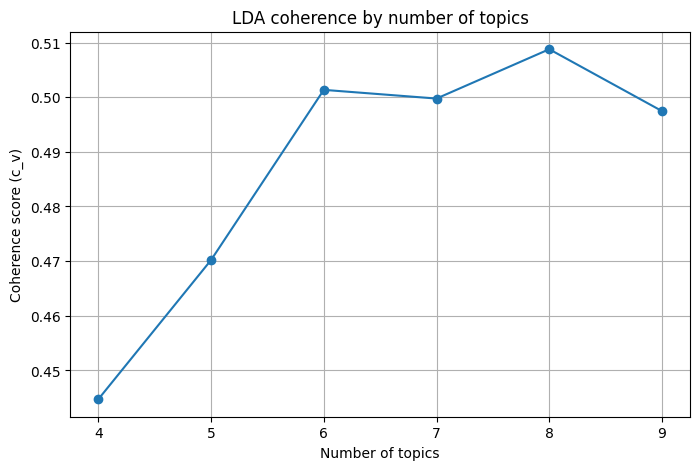

In [39]:
from gensim.models import CoherenceModel
ks = range(4, 10)

coherence_scores = []

for k in ks:
    lda_k = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=8,
        iterations=100,
        alpha="symmetric",
        eta="symmetric",
        random_state=42
    )

    coherence = CoherenceModel(
        model=lda_k,
        texts=texts_bigrams,
        dictionary=dictionary,
        coherence="c_v"
    ).get_coherence()

    coherence_scores.append((k, coherence))

coherence_df = pd.DataFrame(coherence_scores, columns=["num_topics", "coherence"])
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(coherence_df["num_topics"], coherence_df["coherence"], marker="o")
plt.xlabel("Number of topics")
plt.ylabel("Coherence score (c_v)")
plt.title("LDA coherence by number of topics")
plt.grid(True)
plt.show()

Присвоить тему каждому посту

In [7]:
mask = posts["text_topic"].fillna("").str.split().str.len() >= 5

topic_ids = []
topic_probs = []

for bow in corpus:
    topics = lda.get_document_topics(bow)
    main_topic, main_prob = max(topics, key=lambda x: x[1])
    topic_ids.append(main_topic + 1)
    topic_probs.append(main_prob)

posts["topic"] = None
posts["topic_prob"] = None

posts.loc[mask, "topic"] = topic_ids
posts.loc[mask, "topic_prob"] = topic_probs

In [8]:
topic_counts = posts["topic"].value_counts().sort_index()

topic_share = (topic_counts / topic_counts.sum() * 100).round(2)

topic_df = pd.DataFrame({
    "topic": topic_counts.index,
    "count": topic_counts.values,
    "share_%": topic_share.values
})

print(topic_df)

  topic  count  share_%
0     1   1507    31.28
1     2   1104    22.91
2     3    557    11.56
3     4    443     9.19
4     5   1207    25.05


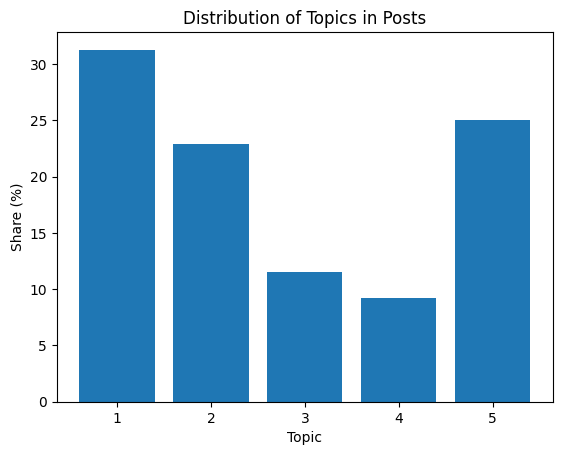

In [9]:
import matplotlib.pyplot as plt

plt.bar(topic_df["topic"], topic_df["share_%"])
plt.xlabel("Topic")
plt.ylabel("Share (%)")
plt.title("Distribution of Topics in Posts")
plt.show()

Тесты

In [10]:
posts["has_replies"] = (posts["reply_posts_count"] > 0).astype(int) #сделали как бинарный признак, 1 - есть ответы на пост 0 - нет

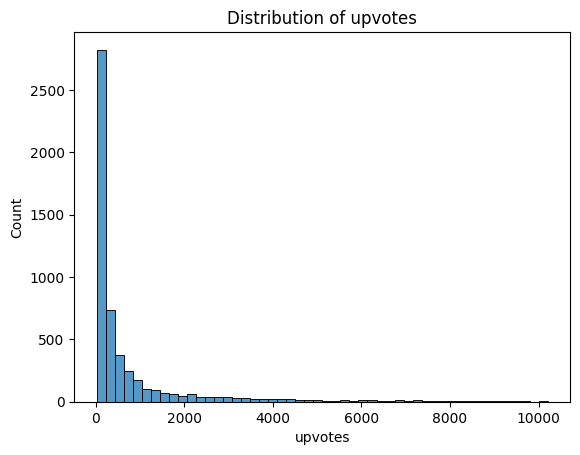

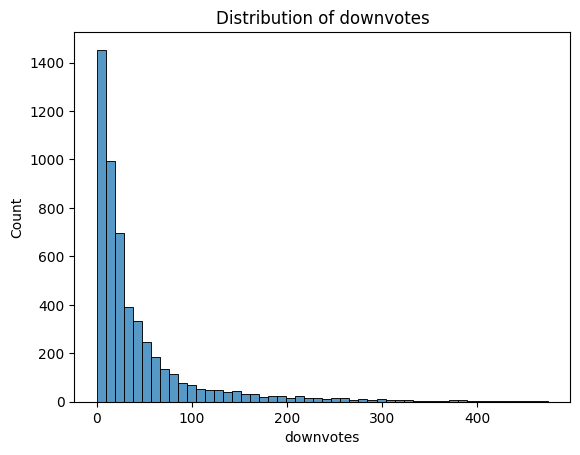

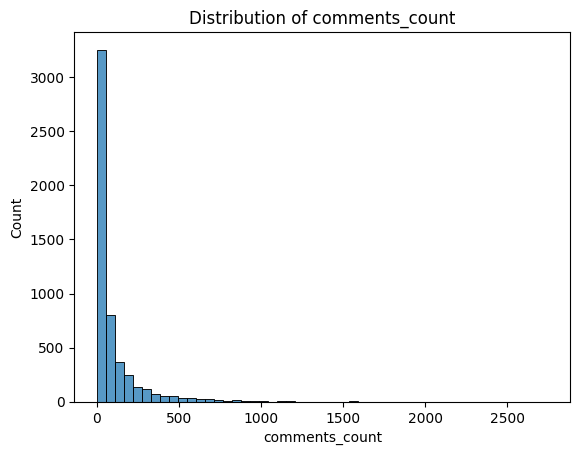

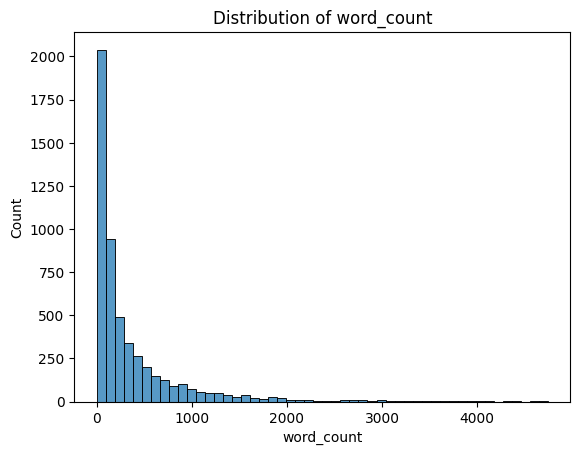

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["upvotes", "downvotes", "comments_count", "word_count"]

for col in metrics:
    plt.figure()
    sns.histplot(posts[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

In [12]:
posts["total_votes"] = posts["upvotes"] + posts["downvotes"]
posts["controversy"] = np.log1p(posts["comments_count"]) / np.log1p(posts["upvotes"] + 1)

In [13]:
from scipy.stats import kruskal

def kruskal_test(metric):
    groups = [g[metric].values for _, g in posts.groupby("topic")]
    stat, p = kruskal(*groups)
    print(f"{metric}: stat={stat:.2f}, p={p:.5f}")

for col in ["upvotes", "comments_count", "downvotes", "controversy","total_votes"]:
    kruskal_test(col)

upvotes: stat=33.78, p=0.00000
comments_count: stat=1474.63, p=0.00000
downvotes: stat=684.18, p=0.00000
controversy: stat=1894.78, p=0.00000
total_votes: stat=32.17, p=0.00000


In [ ]:
#posts.to_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/posts_lda_done.csv", index=False)

In [13]:
import pandas as pd
import numpy as np
posts = pd.read_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/posts_lda_done.csv")

In [10]:
posts.describe()

,post_id,upvotes,downvotes,comments_count,reply_posts_count,score,engagement,text_length,word_count,year,topic,topic_prob,has_replies,total_votes,controversy,comments_log
count,5.298000e+03,5298.000000,5298.000000,5298.000000,5298.000000,5298.000000,5298.00000,5298.000000,5298.000000,5298.000000,4818.000000,4818.000000,5298.000000,5298.000000,5298.000000,5298.000000
mean,1.002613e+07,759.375991,45.502831,97.034164,1.076066,713.873160,98.11023,2594.655908,371.750283,2022.555304,2.738273,0.739867,0.152699,804.878822,0.623653,3.476897
std,1.927664e+06,1440.562297,66.820782,181.331638,28.722555,1392.044721,183.70552,4127.409090,588.207245,1.742120,1.583137,0.195895,0.359731,1490.496894,0.247165,1.585339
min,7.140337e+06,25.000000,0.000000,0.000000,0.000000,13.000000,0.00000,3.000000,1.000000,2020.000000,1.000000,0.233871,0.000000,25.000000,0.000000,0.000000
25%,8.533031e+06,80.000000,8.000000,9.000000,0.000000,62.000000,10.00000,341.250000,46.000000,2021.000000,1.000000,0.574712,0.000000,96.000000,0.474065,2.302585
50%,9.318708e+06,195.000000,21.000000,33.000000,0.000000,173.000000,34.00000,1045.500000,153.000000,2022.000000,2.000000,0.742871,0.000000,220.000000,0.658866,3.526361
75%,1.158295e+07,676.250000,51.000000,101.000000,0.000000,614.750000,101.00000,2989.750000,432.000000,2024.000000,5.000000,0.942744,0.000000,731.500000,0.793042,4.624973
max,1.385418e+07,10209.000000,474.000000,2749.000000,2038.000000,9948.000000,2750.00000,30123.000000,4746.000000,2026.000000,5.000000,0.999743,1.000000,10635.000000,1.360109,7.919356


Различия

In [6]:
!pip install scikit-posthocs

Пост хок (смотрим, где есть эффект)

In [ ]:
from scipy.stats import kruskal
import numpy as np

def kruskal_effect_size(df, metric, group_col="topic"):
    df = df[[metric, group_col]].dropna()

    groups = [g[metric].values for _, g in df.groupby(group_col)]

    H, p = kruskal(*groups)

    n = len(df)
    k = len(groups)

    epsilon_sq = (H - k + 1) / (n - k)

    print(f"{metric}: H={H:.2f}, p={p:.5f}, epsilon^2={epsilon_sq:.4f}")

for col in ["upvotes", "comments_count", "downvotes", "controversy", "total_votes"]:
    kruskal_effect_size(posts, col)

upvotes: H=33.78, p=0.00000, epsilon^2=0.0062
comments_count: H=1474.63, p=0.00000, epsilon^2=0.3056
downvotes: H=684.18, p=0.00000, epsilon^2=0.1413
controversy: H=1894.78, p=0.00000, epsilon^2=0.3928
total_votes: H=32.17, p=0.00000, epsilon^2=0.0059


Для сильновлияющих делаем попарные сравнения

Downvotes

In [42]:
import scikit_posthocs as sp
dunn_df = posts[["topic", "downvotes"]].dropna().copy()

dunn_df["topic"] = dunn_df["topic"].astype(int)
dunn_df["downvotes"] = pd.to_numeric(dunn_df["downvotes"], errors="coerce")

dunn_df = dunn_df.dropna()
posthoc = sp.posthoc_dunn(
    dunn_df,
    val_col="downvotes",
    group_col="topic",
    p_adjust="bonferroni"
)

print(posthoc)

               1             2             3             4              5
1   1.000000e+00  7.194820e-01  3.301830e-30  2.451154e-06  9.325329e-123
2   7.194820e-01  1.000000e+00  2.624622e-21  2.221901e-03   4.934020e-90
3   3.301830e-30  2.624622e-21  1.000000e+00  3.033311e-05   4.280664e-10
4   2.451154e-06  2.221901e-03  3.033311e-05  1.000000e+00   2.942357e-29
5  9.325329e-123  4.934020e-90  4.280664e-10  2.942357e-29   1.000000e+00


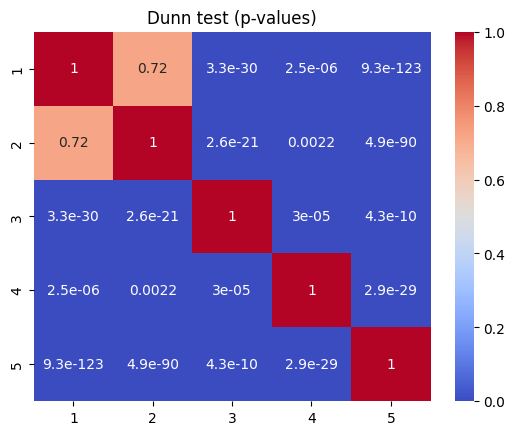

In [43]:
sns.heatmap(posthoc, annot=True, cmap="coolwarm")
plt.title("Dunn test (p-values)")
plt.show()

In [30]:
posts.groupby("topic")["downvotes"].median().sort_values(ascending=False) #смотрим на различия

,downvotes
topic,
1,29.0
2,26.0
4,21.0
3,14.0
5,8.0


<Axes: title={'center': 'downvotes_log'}, xlabel='topic'>

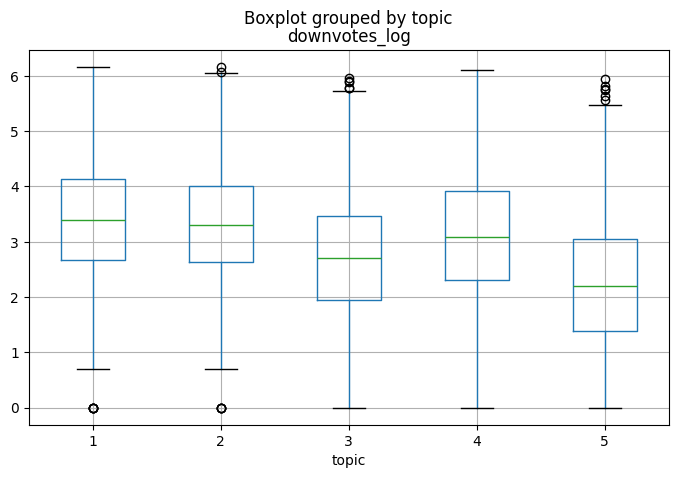

In [41]:
posts.boxplot(
    column="downvotes_log",
    by="topic",
    figsize=(8,5)
)

In [7]:
import scikit_posthocs as sp
dunn_df = posts[["topic", "comments_count"]].dropna().copy()

dunn_df["topic"] = dunn_df["topic"].astype(int)
dunn_df["comments_count"] = pd.to_numeric(dunn_df["comments_count"], errors="coerce")

dunn_df = dunn_df.dropna()
posthoc = sp.posthoc_dunn(
    dunn_df,
    val_col="comments_count",
    group_col="topic",
    p_adjust="bonferroni"
)

print(posthoc)

               1              2             3             4              5
1   1.000000e+00   1.000000e+00  1.195936e-06  8.722325e-04  2.145700e-261
2   1.000000e+00   1.000000e+00  1.013778e-04  1.463570e-02  4.332523e-214
3   1.195936e-06   1.013778e-04  1.000000e+00  1.000000e+00   1.226148e-96
4   8.722325e-04   1.463570e-02  1.000000e+00  1.000000e+00   3.907021e-90
5  2.145700e-261  4.332523e-214  1.226148e-96  3.907021e-90   1.000000e+00


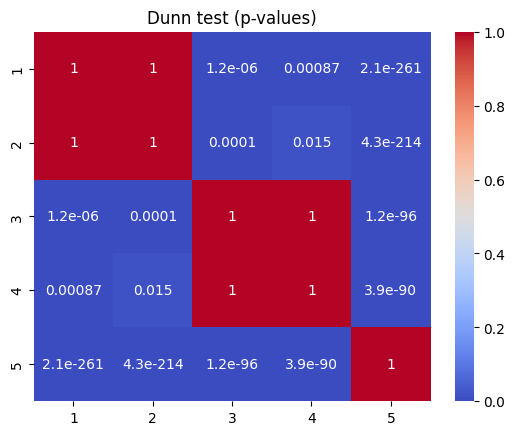

In [45]:
sns.heatmap(posthoc, annot=True, cmap="coolwarm")
plt.title("Dunn test (p-values)")
plt.show()

In [46]:
posts.groupby("topic")["comments_count"].median().sort_values(ascending=False) #смотрим на различия

,comments_count
topic,
1,60.0
2,53.0
4,45.0
3,38.0
5,5.0


<Axes: title={'center': 'comments_log'}, xlabel='topic'>

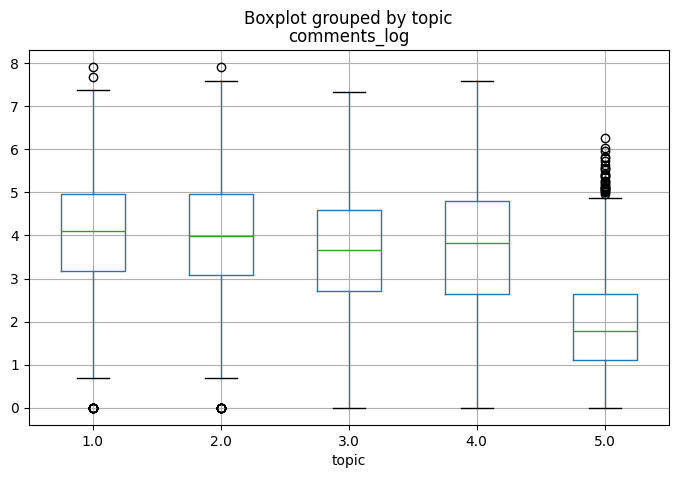

In [9]:
import numpy as np

posts["comments_log"] = np.log1p(posts["comments_count"])

posts.boxplot(
    column="comments_log",
    by="topic",
    figsize=(8,5)
)

In [47]:
dunn_df = posts[["topic", "controversy"]].dropna().copy()

dunn_df["topic"] = dunn_df["topic"].astype(int)
dunn_df["controversy"] = pd.to_numeric(dunn_df["controversy"], errors="coerce")

dunn_df = dunn_df.dropna()
posthoc = sp.posthoc_dunn(
    dunn_df,
    val_col="controversy",
    group_col="topic",
    p_adjust="bonferroni"
)

print(posthoc)

          1              2              3              4              5
1  1.000000   1.000000e+00   2.462622e-03   4.833625e-05   0.000000e+00
2  1.000000   1.000000e+00   1.027433e-04   1.628133e-06  9.586986e-292
3  0.002463   1.027433e-04   1.000000e+00   1.000000e+00  1.040955e-139
4  0.000048   1.628133e-06   1.000000e+00   1.000000e+00  2.485713e-107
5  0.000000  9.586986e-292  1.040955e-139  2.485713e-107   1.000000e+00


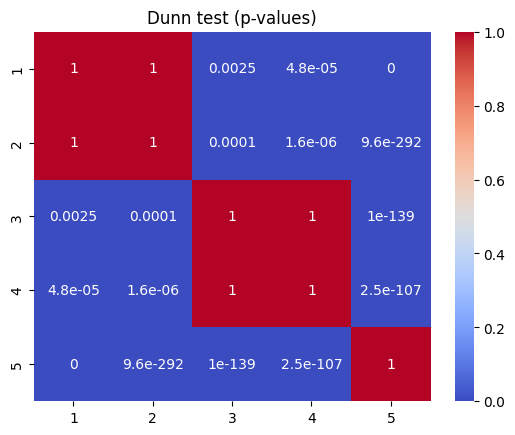

In [48]:
sns.heatmap(posthoc, annot=True, cmap="coolwarm")
plt.title("Dunn test (p-values)")
plt.show()

In [32]:
posts.groupby("topic")["controversy"].median().sort_values(ascending=False) #смотрим на различия

,controversy
topic,
2,0.745160
1,0.740533
3,0.709415
4,0.688334
5,0.333333


<Axes: title={'center': 'controversy'}, xlabel='topic'>

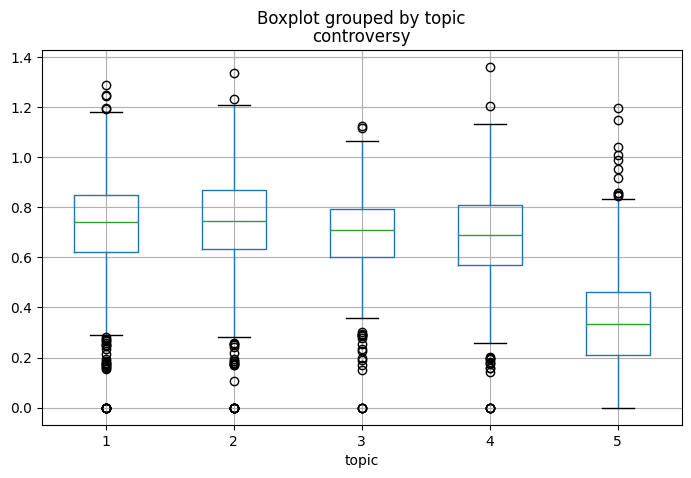

In [33]:
posts.boxplot(column="controversy", by="topic", figsize=(8,5))

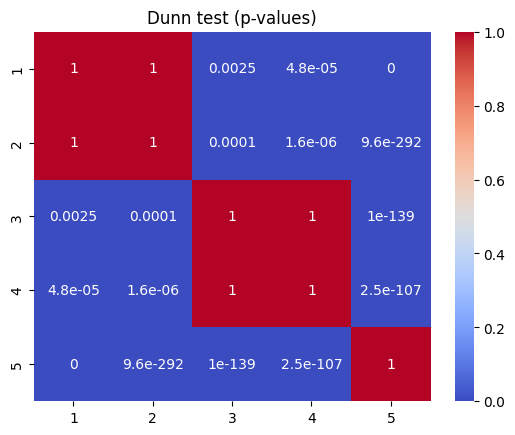

In [40]:
sns.heatmap(posthoc, annot=True, cmap="coolwarm")
plt.title("Dunn test (p-values)")
plt.show()

##SQ 2 Разметили датасет руками теперь обучаем модель

In [51]:
df

,id,post_id,topic,text_clean,stance
0,218955686,8653026,1,к сожалению практика говорит об обратном а мет...,anti
1,177082265,7645702,1,вакцинироваться стоит всем но только после про...,pro
2,303405592,11258699,1,аргументы уровня антипрививочников какие-то эм...,pro
3,209709873,8425372,1,о! мы с коллегой долго сидели с фейспалмом пок...,pro
4,326194510,11932960,1,возможно для вас будет открытием на вакцина сп...,pro
...,...,...,...,...,...
537,182128592,7760440,6,да посрать если честно даже если придётся прик...,pro
538,238940847,7654635,6,а сколько людей пострадало от аллергической вя...,anti
539,304641489,11294159,6,прививка не защищает от заболевания коклюшем о...,pro
540,268575834,10071660,6,жена делала как раз лет в 30 до этого там уже ...,pro


In [52]:
posts

,post_id,title,url,date,upvotes,downvotes,comments_count,reply_posts_count,text,keyword,...,text_clean,text_lemma,text_topic,text_sentiment,topic,topic_prob,has_replies,total_votes,controversy,downvotes_log
0,13488271,В России выпустили три тестовые серии вакцины ...,https://pikabu.ru/story/v_rossii_vyipustili_tr...,2025-12-11 13:35:02+03:00,2964,106,278,0,🧬 В России создали и выпустили первые тестовые...,вакцина,...,в россии выпустили три тестовые серии вакцины ...,в россия выпустить три тестовый серия вакцина ...,россия выпустить тестовый серия вакцина рак ро...,россии выпустили три тестовые серии вакцины от...,4,0.792249,0,3070,0.704344,4.672829
1,13483464,Каждому по барокамере!,https://pikabu.ru/story/kazhdomu_po_barokamere...,2025-12-10 09:10:00+03:00,832,58,94,0,Из канала Мем в глаз попал Также в МАХ,вакцина,...,каждому по барокамере! из канала мем в глаз по...,каждый по барокамере! из канал мем в глаз попа...,барокамере! канал мем глаз попасть мах,каждому по барокамере! из канала мем глаз попа...,1,0.54109,0,890,0.677032,4.077537
2,13352593,В России запустили производство вакцины от вир...,https://pikabu.ru/story/v_rossii_zapustili_pro...,2025-11-01 15:00:00+03:00,1116,56,138,0,💉 В России открыли первое отечественное произв...,вакцина,...,в россии запустили производство вакцины от вир...,в россия запустить производство вакцина от вир...,россия запустить производство вакцина вирус па...,россии запустили производство вакцины от вирус...,2,0.899384,0,1172,0.702987,4.043051
3,13347928,В Кирове начали выпуск первой в России вакцины...,https://pikabu.ru/story/v_kirove_nachali_vyipu...,2025-10-31 11:20:28+03:00,120,19,24,0,В стародавние времена наши далекие предки реши...,вакцина,...,в кирове начали выпуск первой в россии вакцины...,в киров начать выпуск первый в россия вакцина ...,киров начать выпуск россия вакцина против пода...,кирове начали выпуск первой россии вакцины про...,2,0.435847,0,139,0.670038,2.995732
4,13344925,Запущено производство первой российской вакцин...,https://pikabu.ru/story/zapushcheno_proizvodst...,2025-10-30 14:30:46+03:00,7113,126,851,0,Препарат под названием «Цегардекс» разработан ...,вакцина,...,запущено производство первой российской вакцин...,запустить производство первый российский вакци...,запустить производство российский вакцина прот...,запущено производство первой российской вакцин...,2,0.671788,0,7239,0.760723,4.844187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5293,12537415,Эндрю Хуберман нас предал,https://pikabu.ru/story/yendryu_khuberman_nas_...,2025-03-26 22:54:59+03:00,182,48,15,0,Смотреть видео без VPN и замедлений ↗ Disclaim...,прививка от гриппа,...,эндрю хуберман нас предал смотреть видео без v...,эндрю хуберман мы предать смотреть видео без v...,эндрю хуберман предать смотреть vpn замедление...,эндрю хуберман нас предал смотреть видео без v...,3,0.567573,0,230,0.531663,3.891820
5294,7799648,Зооантропонозы. Часть II. Чем мы можем заразит...,https://pikabu.ru/story/zooantroponozyi_chast_...,2020-10-29 13:02:14+03:00,57,5,4,0,"Автор: Целиковский Александр Владимирович , ин...",прививка от гриппа,...,зооантропонозы часть ii чем мы можем заразитьс...,зооантропоноз часть ii чем мы мочь заразиться ...,зооантропоноз часть заразиться домашний питоме...,зооантропонозы часть ii чем мы можем заразитьс...,3,0.602845,0,62,0.394708,1.791759
5295,7706827,Зооантропонозы. Часть I. Чем мы можем заразить...,https://pikabu.ru/story/zooantroponozyi_chast_...,2020-09-10 23:16:44+03:00,70,7,7,0,"Автор: Целиковский Александр Владимирович , ин...",прививка от гриппа,...,зооантропонозы часть i чем мы можем заразиться...,зооантропоноз часть i чем мы мочь заразиться о...,зооантропоноз часть заразиться кошка автор цел...,зооантропонозы часть чем мы можем заразиться о...,3,0.455509,0,77,0.486230,2.079442
5296,13001138,Темная сеть интеллектуалов,https://pikabu.ru/story/temnaya_set_intellektu...,2025-07-25 14:19:41+03:00,174,39,18,0,Смотреть видео без замедлений и VPN

In [6]:
import pandas as pd
import numpy as np
stance = pd.read_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/stance_labeling_pro_anti.csv")
df = stance.copy()
total = len(df)
pro = (df["stance"] == "pro").sum()
anti = (df["stance"] == "anti").sum()

print(f"Всего: {total}")
print(f"Pro: {pro} ({pro/total:.2%})")
print(f"Anti: {anti} ({anti/total:.2%})")

Всего: 542
Pro: 325 (59.96%)
Anti: 217 (40.04%)


In [7]:
table = pd.crosstab(df["topic"], df["stance"])
print(table)

stance  anti  pro
topic            
1         57   73
2         37   67
3         29   37
4         22   45
5         29   28
6         43   75


In [8]:
table_pct = table.div(table.sum(axis=1), axis=0) * 100
print(table_pct.round(2))

stance   anti    pro
topic               
1       43.85  56.15
2       35.58  64.42
3       43.94  56.06
4       32.84  67.16
5       50.88  49.12
6       36.44  63.56


In [9]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("chi2:", chi2)
print("p-value:", p)
print("dof:", dof)

chi2: 6.939027497082842
p-value: 0.22521455112363567
dof: 5


In [10]:
n = table.to_numpy().sum()
r, c = table.shape

cramers_v = np.sqrt(chi2 / (n * min(r - 1, c - 1)))
print("Cramer's V:", cramers_v)

Cramer's V: 0.11314872406905624


In [20]:
posts['topic'].nunique()

5

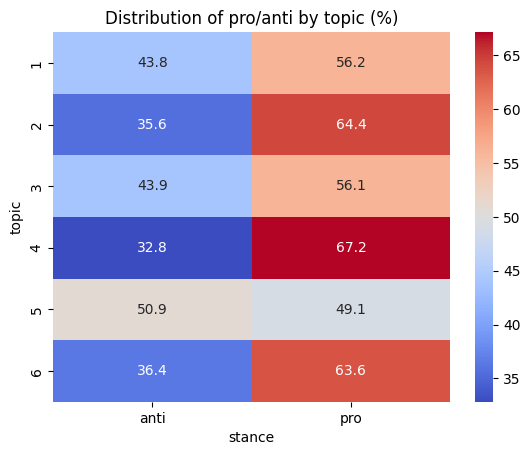

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(table_pct, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Distribution of pro/anti by topic (%)")
plt.show()

SQ3

In [14]:
df = stance.merge(posts[['post_id', 'date']], on='post_id')

In [15]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

/tmp/ipykernel_8271/2815679898.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['date'].dt.to_period('M')


In [16]:
from scipy.stats import chi2_contingency

chi2, p, dof, _ = chi2_contingency(table)

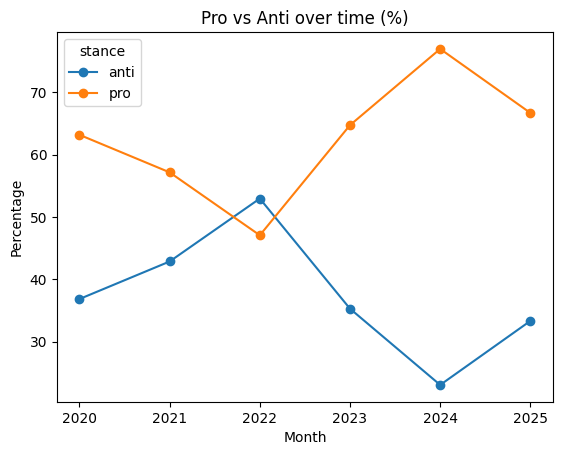

In [17]:
df['year'] = df['date'].dt.year

table3 = pd.crosstab(df['year'], df['stance'])
table_pct3 = table3.div(table3.sum(axis=1), axis=0) * 100

table_pct3.plot(kind='line', marker='o')
plt.title("Pro vs Anti over time (%)")
plt.ylabel("Percentage")
plt.xlabel("Month")
plt.show()

In [86]:
chi2, p, dof, _ = chi2_contingency(table3)
print(chi2, p, dof)

11.74938082826653 0.03838798264912305 5


In [87]:
import numpy as np

n = table3.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(table3.shape)-1)))
print(cramers_v)

0.1537550171157437


In [21]:
df['topic'].nunique()

6

In [89]:
df["period"] = df["year"].apply(lambda x: "2020-2022" if x <= 2022 else "2023-2025")

pd.crosstab(df["period"], df["stance"], normalize="index") * 100

stance,anti,pro
period,,
2020-2022,44.086022,55.913978
2023-2025,30.400000,69.600000


In [90]:
from scipy.stats import spearmanr

years = df["year"]
pro = (df["stance"] == "pro").astype(int)

spearmanr(years, pro)

SignificanceResult(statistic=np.float64(0.05207387992174892), pvalue=np.float64(0.24654912872190596))

In [91]:
import statsmodels.api as sm

df["pro_bin"] = (df["stance"] == "pro").astype(int)

X = sm.add_constant(df["year"])
y = df["pro_bin"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.671783
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                pro_bin   No. Observations:                  497
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            1
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                0.005556
Time:                        22:40:23   Log-Likelihood:                -333.88
converged:                       True   LL-Null:                       -335.74
Covariance Type:            nonrobust   LLR p-value:                   0.05342
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -232.1381    121.708     -1.907      0.056    -470.681       6.405
year           0.1150      0.

In [28]:
posts_lda_ready = pd.read_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/posts_lda_done.csv")
posts_lda_ready['topic'].unique()

array([ 4.,  1.,  2., nan,  3.,  5.])

In [33]:
posts_lda_ready.head(1)

,post_id,title,url,date,upvotes,downvotes,comments_count,reply_posts_count,text,keyword,...,month,text_clean,text_lemma,text_topic,text_sentiment,topic,topic_prob,has_replies,total_votes,controversy
0,13488271,В России выпустили три тестовые серии вакцины ...,https://pikabu.ru/story/v_rossii_vyipustili_tr...,2025-12-11 13:35:02+03:00,2964,106,278,0,🧬 В России создали и выпустили первые тестовые...,вакцина,...,2025-12,в россии выпустили три тестовые серии вакцины ...,в россия выпустить три тестовый серия вакцина ...,россия выпустить тестовый серия вакцина рак ро...,россии выпустили три тестовые серии вакцины от...,4.0,0.792249,0,3070,0.704344


In [31]:
posts_lda_ready.groupby('topic').size()

,0
topic,
1.0,1507
2.0,1104
3.0,557
4.0,443
5.0,1207


In [23]:
stance = stance.drop(columns=["topic"], errors="ignore")
stance
#posts = pd.read_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/posts_la_final.csv")

,id,post_id,text_clean,stance
0,218955686,8653026,к сожалению практика говорит об обратном а мет...,anti
1,177082265,7645702,вакцинироваться стоит всем но только после про...,pro
2,303405592,11258699,аргументы уровня антипрививочников какие-то эм...,pro
3,209709873,8425372,о! мы с коллегой долго сидели с фейспалмом пок...,pro
4,326194510,11932960,возможно для вас будет открытием на вакцина сп...,pro
...,...,...,...,...
537,182128592,7760440,да посрать если честно даже если придётся прик...,pro
538,238940847,7654635,а сколько людей пострадало от аллергической вя...,anti
539,304641489,11294159,прививка не защищает от заболевания коклюшем о...,pro
540,268575834,10071660,жена делала как раз лет в 30 до этого там уже ...,pro


In [ ]:
# merge
data_posts_with_labeled_comments = stance.merge(posts_lda_ready[['post_id', 'date', 'topic']], on = 'post_id')

In [40]:
data_posts_with_labeled_comments.groupby('topic', dropna=False).size()

,0
topic,
1.0,234
2.0,112
3.0,25
4.0,60
5.0,1
NaN,65


In [39]:
data_posts_with_labeled_comments.groupby('topic').count()

,id,post_id,text_clean,stance,date
topic,,,,,
1.0,234,234,234,234,234
2.0,112,112,112,112,112
3.0,25,25,25,25,25
4.0,60,60,60,60,60
5.0,1,1,1,1,1


In [46]:
import datetime as dt
data_posts_with_labeled_comments['date'] = pd.to_datetime(data_posts_with_labeled_comments['date'], utc=False)

In [49]:
data_posts_with_labeled_comments['year'] = data_posts_with_labeled_comments['date'].dt.year
data_posts_with_labeled_comments.head(1)

,id,post_id,text_clean,stance,date,topic,year
0,218955686,8653026,к сожалению практика говорит об обратном а мет...,anti,2021-11-30 08:22:16+03:00,2.0,2021


In [50]:
data_posts_with_labeled_comments.groupby('year', dropna = False).size()

,0
year,
2020,38
2021,266
2022,68
2023,17
2024,39
2025,69


In [52]:
SQ23 =  data_posts_with_labeled_comments.dropna(subset = ['topic'])

In [53]:
SQ23

,id,post_id,text_clean,stance,date,topic,year
0,218955686,8653026,к сожалению практика говорит об обратном а мет...,anti,2021-11-30 08:22:16+03:00,2.0,2021
2,303405592,11258699,аргументы уровня антипрививочников какие-то эм...,pro,2024-03-25 11:00:00+03:00,4.0,2024
3,209709873,8425372,о! мы с коллегой долго сидели с фейспалмом пок...,pro,2021-08-22 11:05:00+03:00,1.0,2021
4,326194510,11932960,возможно для вас будет открытием на вакцина сп...,pro,2024-10-21 08:00:00+03:00,1.0,2024
5,206171609,8342051,на самом деле идея вакцинации очень простая и ...,pro,2021-07-14 10:29:05+03:00,4.0,2021
...,...,...,...,...,...,...,...
492,182128592,7760440,да посрать если честно даже если придётся прик...,pro,2020-10-08 20:40:44+03:00,1.0,2020
493,238940847,7654635,а сколько людей пострадало от аллергической вя...,anti,2020-08-16 11:00:26+03:00,4.0,2020
494,304641489,11294159,прививка не защищает от заболевания коклюшем о...,pro,2024-04-05 16:49:24+03:00,1.0,2024
495,268575834,10071660,жена делала как раз лет в 30 до этого там уже ...,pro,2023-03-24 12:58:06+03:00,1.0,2023


In [54]:
comments

,author,author_id,id,indent,rating,text,post_id,text_length,word_count,is_reply
0,Elya20,804806.0,376393288,0,460.0,Чтоб все получилось! Чтоб массово люди начали ...,13488271,75,11,False
1,Archi77,1008009.0,376434095,1,17.0,От какой именно? От какого именно из тысяч вид...,13488271,188,34,True
2,PlagueMen,1297286.0,376435162,2,5.0,"В чем же и фишка, вакцина не от всех видов рак...",13488271,202,35,True
3,Ghostevg,844934.0,376443914,3,13.0,Препарат предназначен для борьбы с меланомой и...,13488271,250,39,True
4,PlagueMen,1297286.0,376454356,4,3.0,Выпускается серия вакцин для меланомы (как в с...,13488271,213,34,True
...,...,...,...,...,...,...,...,...,...,...
159057,PavleB,1270977.0,332349835,2,0.0,"ФИП(FIP) - это болезнь, вызываемая коронавирус...",12115024,54,7,True
159058,SooooMadAo,2703343.0,332467151,3,0.0,"я это и сказала. Лечат не коронавирус, а ФИП. ...",12115024,223,36,True
159059,Animalrescueed,2534152.0,332240756,1,0.0,Я не знаю. Нашла такую статью.https://vk.com/w...,12115024,65,6,True
159060,PavleB,1270977.0,332252481,2,0.0,И там нирматрелвир+ритонавир работает лучше. Н...,12115024,150,19,True


отбор для нормальной разметки

In [ ]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42
TARGET_N = 2000

# 1. Берём комментарии
comments_base = comments.copy()
posts_base = posts_lda_ready[["post_id", "date", "topic"]].copy()

# 2. Приводим id к одному типу, чтобы merge не сломался
comments_base["post_id"] = comments_base["post_id"].astype(str)
posts_base["post_id"] = posts_base["post_id"].astype(str)
comments_base["id"] = comments_base["id"].astype(str)

# 3. Склеиваем комментарии с финальной темой поста
pool = comments_base.merge(
    posts_base,
    on="post_id",
    how="left"
)

# 4. Убираем комментарии без темы и без текста
pool = pool.dropna(subset=["topic", "text"]).copy()

pool["topic"] = pool["topic"].astype(int)
pool["date"] = pd.to_datetime(pool["date"], errors="coerce")
pool = pool.dropna(subset=["date"]).copy()
pool["year"] = pool["date"].dt.year

# 5. Фильтр по длине: убираем слишком короткие комменты
pool = pool[
    (pool["text_length"] >= 30) &
    (pool["word_count"] >= 5)
].copy()

# 6. Убираем дубли по id
pool = pool.drop_duplicates(subset=["id"]).copy()

# 7. Считаем, сколько есть ячеек topic × year
cell_counts = pool.groupby(["topic", "year"]).size()
n_cells = len(cell_counts)

N_PER_CELL = TARGET_N // n_cells

print("Ячеек topic × year:", n_cells)
print("Базовая квота на ячейку:", N_PER_CELL)

# 8. Берём базовую стратифицированную выборку
base_sample = (
    pool
    .groupby(["topic", "year"], group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), N_PER_CELL), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)


Ячеек topic × year: 34
Базовая квота на ячейку: 58


/tmp/ipykernel_8271/3690543825.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), N_PER_CELL), random_state=RANDOM_STATE))


In [56]:
# 9. Добираем остаток до 2000 случайно из оставшегося пула
need_more = TARGET_N - len(base_sample)

remaining_pool = pool[~pool["id"].isin(base_sample["id"])].copy()

if need_more > 0:
    extra_sample = remaining_pool.sample(
        n=min(need_more, len(remaining_pool)),
        random_state=RANDOM_STATE
    )
    final_sample = pd.concat([base_sample, extra_sample], ignore_index=True)
else:
    final_sample = base_sample.copy()

# 10. Перемешиваем итоговую выборку
final_sample = final_sample.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# 11. Оставляем колонки для разметки
final_sample = final_sample[
    ["id", "post_id", "topic", "year", "text", "text_length", "word_count"]
].copy()

final_sample

,id,post_id,topic,year,text,text_length,word_count
0,382860998,13685712,5,2026,Вот да. В ковидное лето было классно. Пустые ч...,142,26
1,388431256,13851237,1,2026,симптомы поражения головного мозга у зараженно...,57,7
2,293659254,10963607,4,2023,"Сколько было проб и ошибок, сколько было мальч...",53,8
3,224484516,8792421,3,2022,А как вы дома посидите без больничного? Уволит...,56,10
4,232700054,8991008,4,2022,Чувак выглядит как участник съёмок короткометр...,71,9
...,...,...,...,...,...,...,...
1995,380596343,13617993,3,2026,"Мне кажется, в статье на майле написано подроб...",2133,259
1996,223552558,8768839,4,2022,Так если мы говорим про смертность по отношени...,181,28
1997,220918795,8700918,3,2021,Может быть - то же самое было и в Германии (ви...,172,31
1998,364625570,13100446,4,2025,У ребенка 2 инсульта? Там совсем беда с сосуда...,55,11


In [59]:
# 12. Подтягиваем старую ручную разметку, если есть

old_stance = pd.read_csv("/content/drive/MyDrive/Диплом_Артема_Хугаева/stance_labeling_pro_anti.csv")
old_stance["id"] = old_stance["id"].astype(str)

old_stance = old_stance[["id", "stance"]].drop_duplicates(subset=["id"])

final_sample = final_sample.merge(
    old_stance,
    on="id",
    how="left"
)

final_sample

,id,post_id,topic,year,text,text_length,word_count,stance
0,382860998,13685712,5,2026,Вот да. В ковидное лето было классно. Пустые ч...,142,26,NaN
1,388431256,13851237,1,2026,симптомы поражения головного мозга у зараженно...,57,7,NaN
2,293659254,10963607,4,2023,"Сколько было проб и ошибок, сколько было мальч...",53,8,NaN
3,224484516,8792421,3,2022,А как вы дома посидите без больничного? Уволит...,56,10,NaN
4,232700054,8991008,4,2022,Чувак выглядит как участник съёмок короткометр...,71,9,NaN
...,...,...,...,...,...,...,...,...
1995,380596343,13617993,3,2026,"Мне кажется, в статье на майле написано подроб...",2133,259,NaN
1996,223552558,8768839,4,2022,Так если мы говорим про смертность по отношени...,181,28,NaN
1997,220918795,8700918,3,2021,Может быть - то же самое было и в Германии (ви...,172,31,NaN
1998,364625570,13100446,4,2025,У ребенка 2 инсульта? Там совсем беда с сосуда...,55,11,NaN


In [60]:
already_labeled = final_sample["stance"].notna().sum()
need_to_label = final_sample["stance"].isna().sum()

final_sample["stance"] = final_sample["stance"].fillna("")

# 13. Сохраняем полный файл для разметки
final_sample.to_csv(
    "/content/drive/MyDrive/Диплом_Артема_Хугаева/final_stance_sample_2000.csv",
    index=False
)

# 14. Отдельно сохраняем только то, что надо доразметить
to_label = final_sample[final_sample["stance"] == ""].copy()

to_label.to_csv(
    "/content/drive/MyDrive/Диплом_Артема_Хугаева/to_label_only.csv",
    index=False
)

print("Итоговая выборка:", final_sample.shape)
print("Уже размечено:", already_labeled)
print("Нужно доразметить:", need_to_label)

print("\nРаспределение по topic:")
print(final_sample["topic"].value_counts().sort_index())

print("\nРаспределение по year:")
print(final_sample["year"].value_counts().sort_index())

print("\nМатрица topic × year:")
print(pd.crosstab(final_sample["topic"], final_sample["year"]))

Итоговая выборка: (2000, 8)
Уже размечено: 10
Нужно доразметить: 1990

Распределение по topic:
topic
1    438
2    394
3    401
4    359
5    408
Name: count, dtype: int64

Распределение по year:
year
2020    294
2021    343
2022    316
2023    297
2024    292
2025    295
2026    163
Name: count, dtype: int64

Матрица topic × year:
year   2020  2021  2022  2023  2024  2025  2026
topic                                          
1        61    80    73    61    58    61    44
2        58    82    62    62    59    60    11
3        58    60    59    58    58    58    50
4        59    62    63    58    59    58     0
5        58    59    59    58    58    58    58
